# LiDAR Cloud Data Processing
by Kooros Moabber from Luleå univesity and Volvocars

## Introduction
LiDAR (Light Detection and Ranging) is a sensing technology that uses laser pulses to measure distances. the concept is:
- Transmit LASER beam
- Scanned by rotating mirrors
- Reflection sampled
- Time of flight to measure distance
therefore LiDAR creates a 3D representation of the surrounding environment.
The generated data, known as a point cloud, consists of thousands of points with (x,y,z) coordinates that describe the position of objects in space.

LiDAR is widely used in areas such as autonomous vehicles (active safety), railway systems, mapping, robotics, and infrastructure inspection because it can capture accurate spatial information even in complex environments.

In this assignment, two semi-processed LiDAR datasets were analyzed by using Python. The main goal was to identify the catenary structure from the point cloud data.
  

## Method
The work started by estimating the ground level using histogram analysis and removing the ground points from the dataset. 

After that, the DBSCAN clustering algorithm was applied to group nearby points into clusters. Different epsilon values were studied using the elbow/knee method in order to find a suitable clustering parameter. 

Finally, the largest cluster was extracted as the catenary structure using its geometric properties. This assignment provided practical experience in LiDAR data processing, clustering methods, and point cloud analysis using machine learning techniques.

## Analysis and Resullts
To start analysis, first libraries shall be loaded.

In [1]:
import matplotlib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial import KDTree
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.spatial import KDTree
from kneed import KneeLocator

There are two datasets that should be analyzed in parallel and in different part of whole code therefore most of operations are codded in functions to avoid long repeated code. Functions are:
- show_cloud: show cloud for two datasets
- get_ground_level: calculate the level of ground based on histogram method and specific margins
- plot_histograms: show both histogram
- biggest_cluster: extract the biggest cluster based on its span 

In [2]:

def show_cloud(pcd1,pcd2,
                    filename="temp",
                    figsize=(10, 3),
                    title1="Dataset1",
                    title2="Dataset2"
                    ):
    fig = plt.figure(figsize=(15, 9))
    
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(pcd1[:,0], pcd1[:,1], pcd1[:,2], s=0.01)
    ax1.set_title(f"{title1}")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(pcd2[:,0], pcd2[:,1], pcd2[:,2], s=0.01)
    ax2.set_title(f"{title2}")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")
    
    plt.tight_layout()
    plt.show()
    fig.savefig(filename, dpi=300, bbox_inches='tight')


def get_ground_level(pcd,bin_size,ground_margin):
    z = pcd[:,2]
    hist, bins = np.histogram(z, bins=bin_size)
    max_bin_index = np.argmax(hist)
    bin_center = (bins[max_bin_index]+bins[max_bin_index + 1]) / 2
    ground_level = bin_center+ground_margin
    return ground_level


def plot_histograms(pcd1,pcd2,
                    filename="temp",
                    zoom_range1=(-1,-1),
                    zoom_range2=(-1,-1),
                    bin_size=50,
                    column=2,
                    figsize=(10, 3),
                    title1="Dataset1",
                    title2="Dataset2"):

    fig = plt.figure(figsize=figsize)

    if zoom_range1==(-1,-1):
        zoom_range1=(pcd1[:, column].min(),pcd1[:, column].max())
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.hist(pcd1[:, column], bins=bin_size, range=zoom_range1)
    ax1.set_title(f"Hist. {title1}")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")

    if zoom_range2==(-1,-1):
        zoom_range2=(pcd2[:, column].min(),pcd2[:, column].max())
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.hist(pcd2[:, column], bins=bin_size, range=zoom_range2)
    ax2.set_title(f"Hist. {title2}")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")

    plt.tight_layout()
    plt.show()
    fig.savefig(filename, dpi=300, bbox_inches='tight')

def biggest_cluster(pcd, labels):
    selected_point=0
    selected_label=0
    selected_span=0

    for label in np.unique(labels):
        points=pcd[labels==label]
        span_x=np.max(points[:,0])-np.min(points[:,0])
        span_y=np.max(points[:,1])-np.min(points[:,1])
        span_total=span_x+span_y # span_total=sqrt(span_x^2+span_y^2) 
        if span_total>selected_span:
            selected_span=span_total
            selected_point=points
            selected_label=label
    return{
        "span":selected_span,
        "points":selected_point,
        "label":selected_label
    }

def cluster_data_show(catenary,label):
    print(f"{label}: ")
    print(f"Cluster Label : {catenary['label']}")
    print(f"Cluster span: {catenary['span']:.3f}")
    print(f"min(x) of dataset1 : {np.min(catenary1['points'][:,0]):.3f}")
    print(f"max(x) : {np.max(catenary['points'][:,0]):.3f}")
    print(f"min(y) : {np.min(catenary['points'][:,1]):.3f}")
    print(f"max(y) : {np.max(catenary['points'][:,1]):.3f}\n")


In this step, two datasets are read and size of them is investigated.

In [3]:
pcd1 = np.load("dataset1.npy")
pcd2 = np.load("dataset2.npy")
pcd1.shape , pcd2.shape

((72067, 3), (84588, 3))

### Visualize Datasets 
In this part, two datasets clouds are illustrated. The written function is used for this purpose.

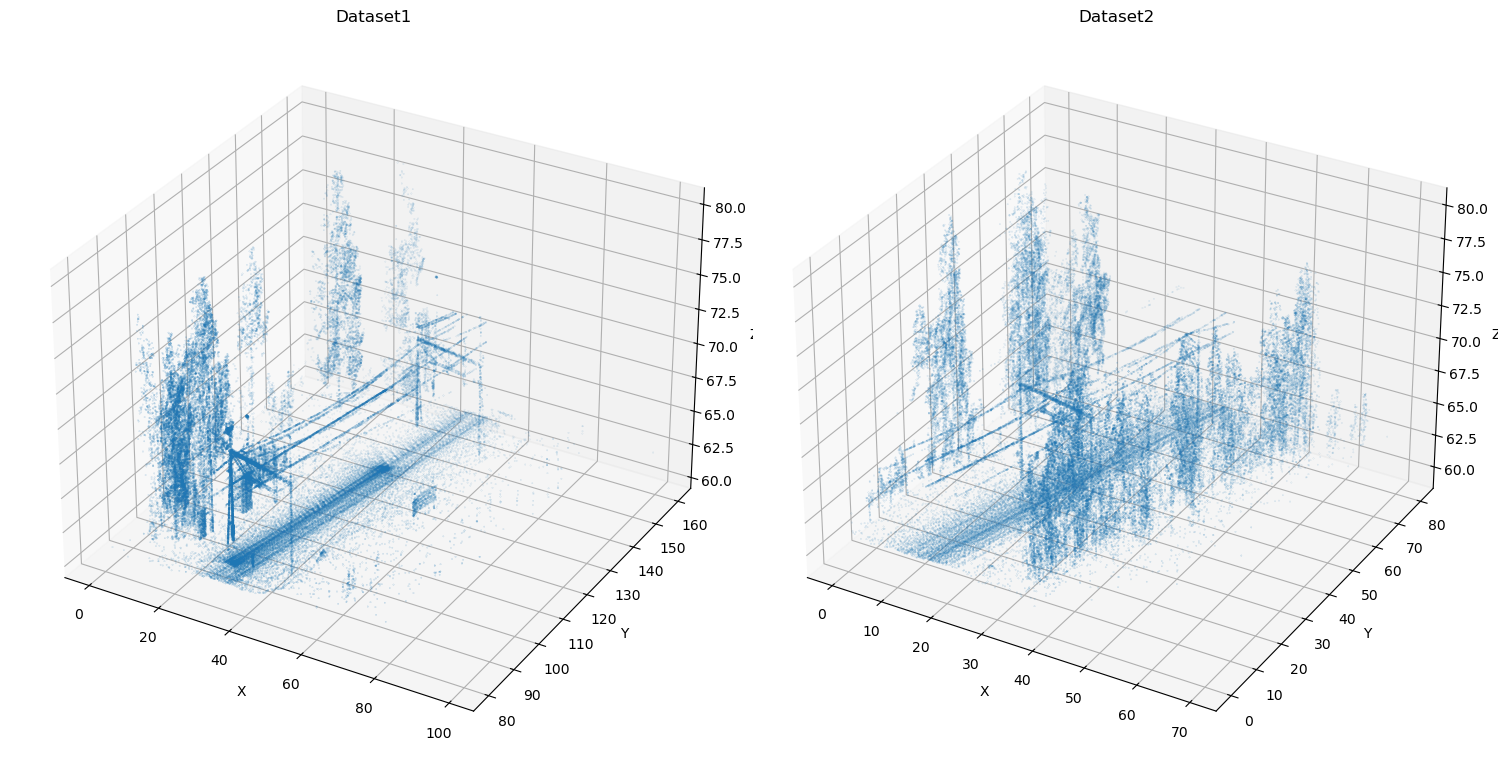

In [4]:
%matplotlib inline
# %matplotlib qt
show_cloud(pcd1,pcd2,"Cloud.png")

There are many objects that can clearly be recognized visually: ground, catenaries, trees and other objects. they should be distinguished separately by clustering later in this report. 

Sometimes to reduce the extra unnecessary calculations, down sampling can be hejpful to reduce this overhead therefore in this step datasets are down sampled and visualized.

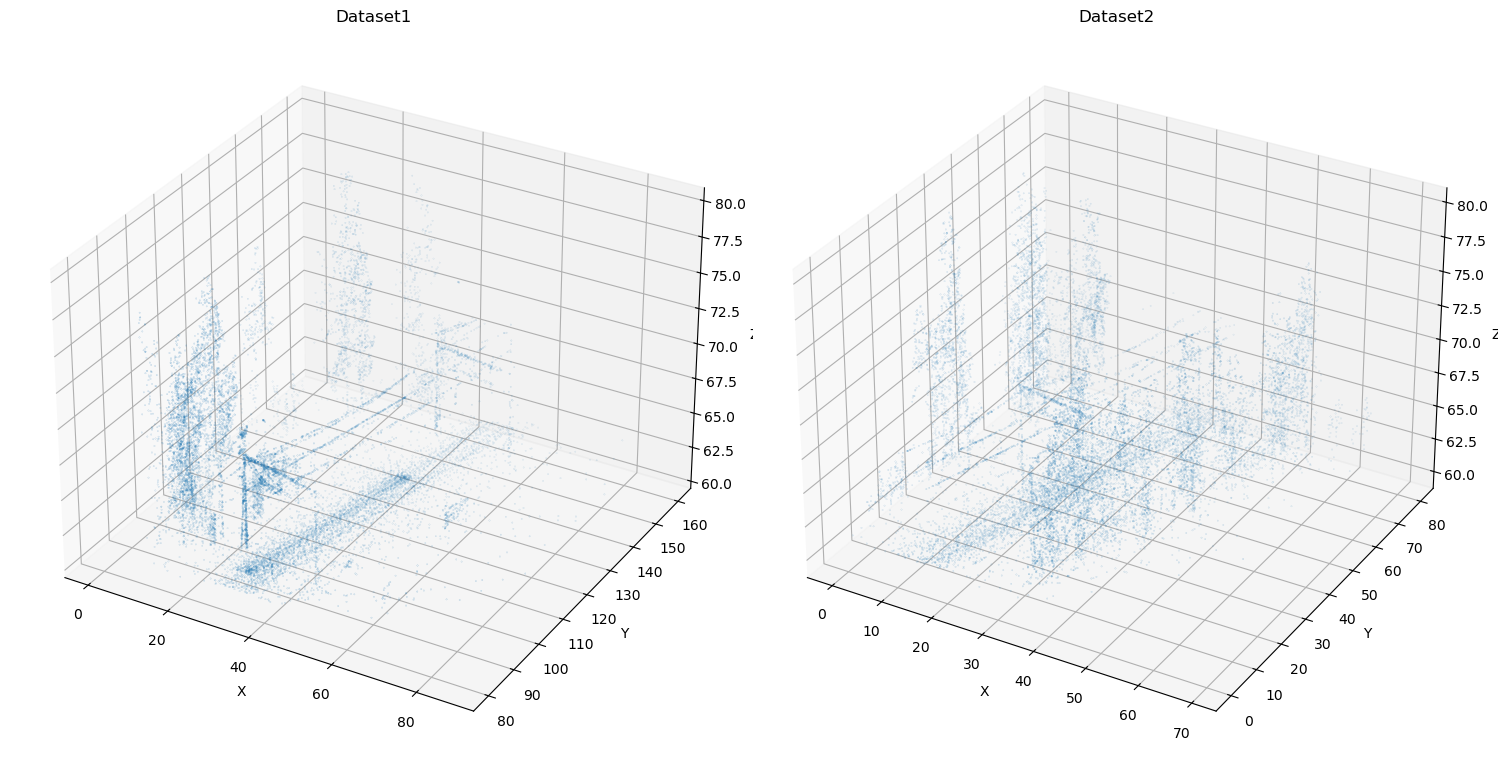

In [5]:
ds_ratio=5 # Downsampling ratio
pcd1_ds=pcd1[::ds_ratio]
pcd2_ds=pcd2[::ds_ratio]
show_cloud(pcd1_ds,pcd2_ds,"Cloud_Downsized.png")

This down sampling shows that objects are less recognizable therefore I will continue with original data.

### Ground Plane Removal
Ground points dominate the dataset. Ground plane may contain up to 60% of the points to reduce processing overhead.
Besides, If not removed, DBSCAN will mostly cluster the ground and consider it as the biggest cluster therefore overhead wires/catenary become difficult to detect.

One way to do it is using a histogram. 
Ground points are usually:
- the MOST COMMON height values in histogram
- concentrated around one z-level
The largest peak often corresponds to ground.

First we look at histogram of Z values.

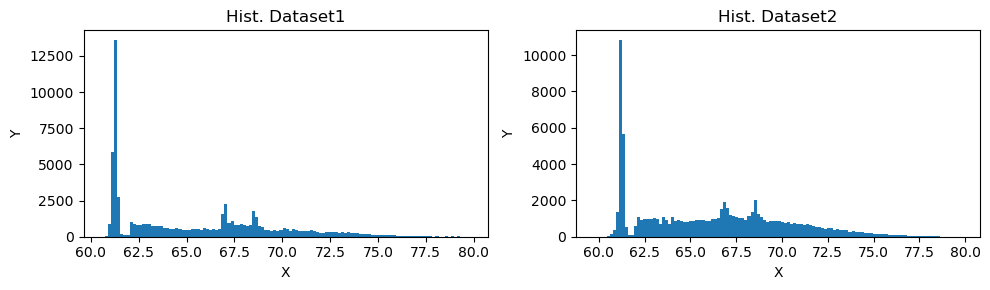

In [6]:
bin_size=120 # Number of histogram bins 
plot_histograms(pcd1, pcd2,"Histogram_initial.png",
                bin_size=bin_size)


As it can be visualized most of z data is gathered around 60 to 62.5 which is corresponded to ground level. To select the right value, let's zoom in in histogram in this range.

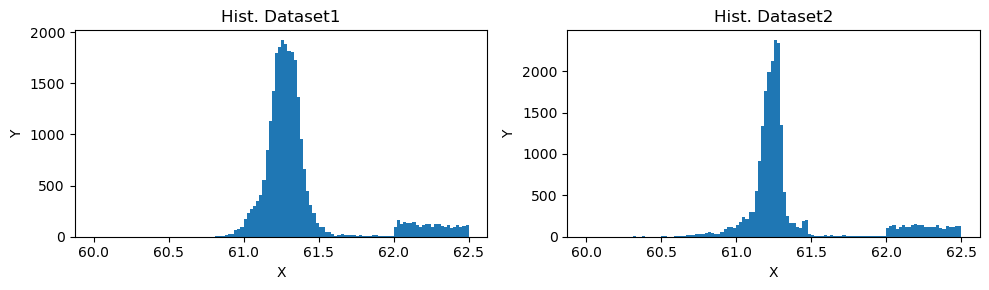

In [7]:
plot_histograms(pcd1, pcd2, "Histogram_zoomed.png",
                zoom_range1=(60,62.5),
                zoom_range2=(60,62.5),
                bin_size=bin_size)

This figures show that even peaks happen in another positions, there is a need to consider some spans as margins for removal of ground safely. Based on this zoomed figures some margins around 0.7 to 0.8 from peaks can remove whole ground more safe.

This is done in below codes:
- selected items considered ground from histogram
- remove those ground points

In [8]:
margin1=0.7
margin2=0.8
est_ground_level1 = get_ground_level(pcd1,bin_size,margin1)
est_ground_level2 = get_ground_level(pcd2,bin_size,margin2)
print(f"Ground level for dataset 1= {est_ground_level1}")
print(f"Ground level for dataset 2= {est_ground_level2}")

Ground level for dataset 1= 61.99766250000003
Ground level for dataset 2= 61.981925


In [9]:
pcd1_above_ground = pcd1[pcd1[:,2] > est_ground_level1]
pcd2_above_ground = pcd2[pcd2[:,2] > est_ground_level2]
print(f"Compression ratio dataset 1= {len(pcd1_above_ground)/len(pcd1)}")
print(f"Compression ratio dataset 2= {len(pcd2_above_ground)/len(pcd2)}")

Compression ratio dataset 1= 0.6744557148209305
Compression ratio dataset 2= 0.7745543103040621


To visualize the data, first we can look at histogram

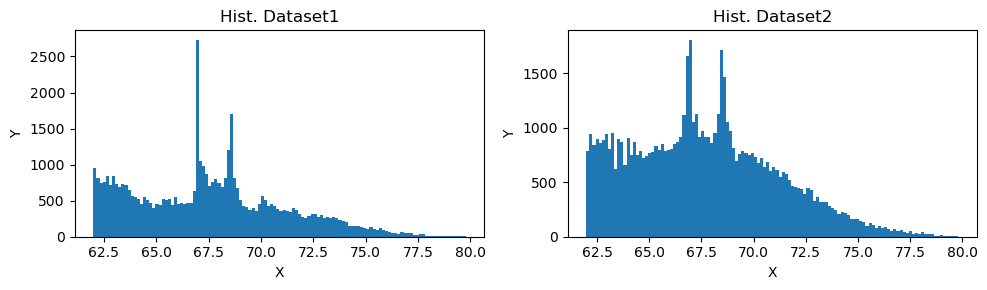

In [10]:
plot_histograms(pcd1_above_ground, pcd2_above_ground, "Histogram_withoutground.png",
                bin_size=bin_size)


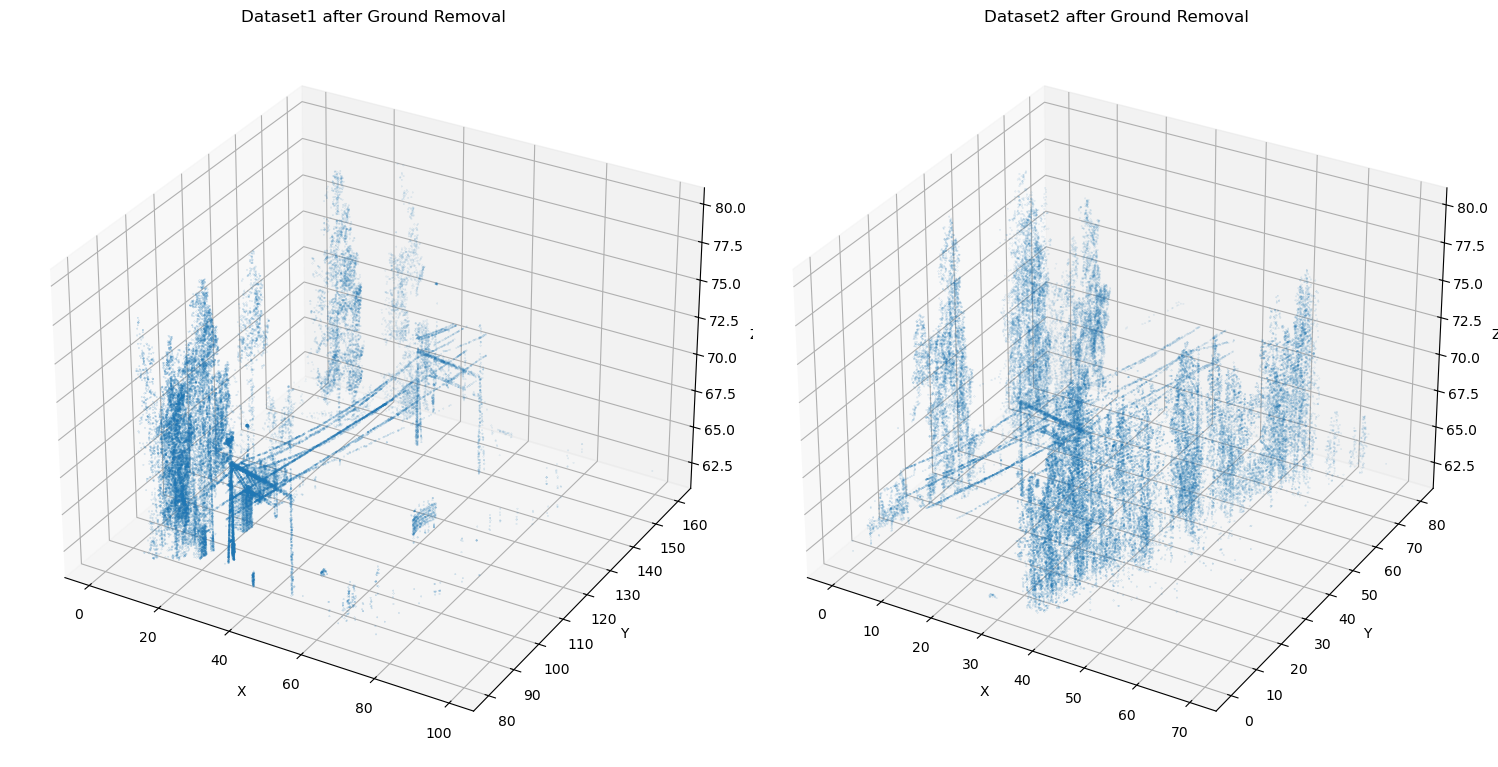

In [11]:
show_cloud(pcd1_above_ground,pcd2_above_ground, "Cloud_withoutground.png",
           title1="Dataset1 after Ground Removal",
           title2="Dataset2 after Ground Removal")

### DBSCAN Analysis for Clustering
Density-based spatial clustering of applications with noise (DBSCAN) is an algorithm to cluster neighboring points in eps radius
This clustering model has two important parameters:
- eps: Neighborhood radius. eps is very important parameter since:
    - Small eps: many tiny clusters / many noise points
    - Large eps: clusters merge together
- min_sample: Minimum number of neighboring points in eps radius required to form a dense region.
Then DBSCAN:
- examines every point,
- finds neighboring points within distance eps,
- groups dense regions into clusters,
- labels isolated points as noise.

This runs the DBSCAN clustering algorithm on data without optimal epsilon (radius). 
The returned object contains clustering results (-1 for noise (not clustered) and 0, 1, 2, ... for clusters).

In [12]:
min_samples1 = 5
min_samples2 = 5

unoptimal_eps1 = 5
unoptimal_eps2 = 5

# find the elbow
clustering1 = DBSCAN(eps = unoptimal_eps1, min_samples=min_samples1).fit(pcd1_above_ground)
clustering2 = DBSCAN(eps = unoptimal_eps2, min_samples=min_samples2).fit(pcd2_above_ground)
labels1 = clustering1.labels_
labels2 = clustering2.labels_

Clustering groups are recorded in labels_ attribute of clustering.

Before looking at clusters visualization, color is individually assigned to each cluster (excluding noise if there is available).

In [13]:
clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)
colors1 = [plt.cm.tab10(each) for each in np.linspace(0, 1, clusters1)]
clusters2 = len(set(labels2)) - (1 if -1 in labels2 else 0)
colors2 = [plt.cm.tab10(each) for each in np.linspace(0, 1, clusters2)]
print(f"Number of cluster:dataset1= {clusters1}, dataset2= {clusters2}")

Number of cluster:dataset1= 11, dataset2= 4


The results of clustering is plotted as follow:

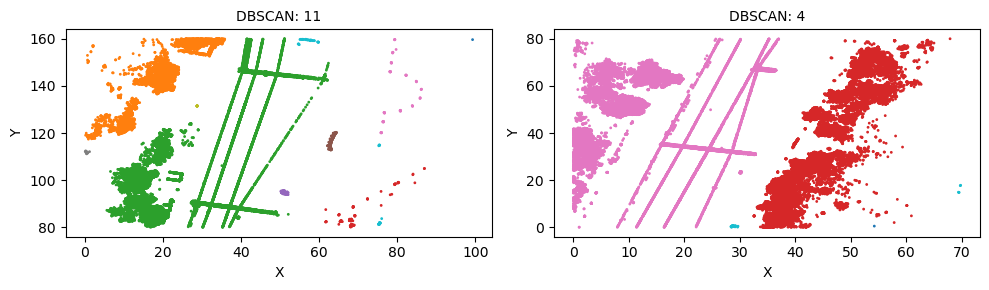

In [14]:
fig = plt.figure(figsize=(10,3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(pcd1_above_ground[:,0], 
            pcd1_above_ground[:,1],
            c=labels1,
            cmap=matplotlib.colors.ListedColormap(colors1),
            s=1)
ax1.set_title(f"DBSCAN: {clusters1}" ,fontsize=10)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pcd2_above_ground[:,0], 
            pcd2_above_ground[:,1],
            c=labels2,
            cmap=matplotlib.colors.ListedColormap(colors2),
            s=1)
ax2.set_title(f"DBSCAN: {clusters2}" ,fontsize=10)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()
filename="Clustered_Cloud_withoutground_unoptimal_eps.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')

Before to select eps value, let's investigate about the effect of eps and minimum sample in DBSCAN method on number of cluster.

Following code calculate these values:

In [15]:
eps = [0.5, 1, 1.5, 2, 2.5, 5] #
min_samples = [3, 5, 10, 15, 20] # 
acc=[]
for optimal_eps1 in eps:
    optimal_eps2=optimal_eps1
    for min_samples1 in min_samples:
        min_samples2=min_samples1   
        clustering1 = DBSCAN(eps = optimal_eps1, min_samples=min_samples1).fit(pcd1_above_ground)
        clustering2 = DBSCAN(eps = optimal_eps2, min_samples=min_samples2).fit(pcd2_above_ground)
        labels1 = clustering1.labels_
        labels2 = clustering2.labels_
        clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)
        colors1 = [plt.cm.Spectral(each) for each in np.linspace(0, 1, clusters1)]
        clusters2 = len(set(labels2)) - (1 if -1 in labels2 else 0)
        colors2 = [plt.cm.Spectral(each) for each in np.linspace(0, 1, clusters2)]
        # print(f"eps={optimal_eps1}, min_sample={min_samples1}, number of cluster:dataset1= {clusters1}, dataset2= {clusters2}")
        acc.append([optimal_eps1, min_samples1, clusters1, clusters2])

Let's look at the number of clusters change versus eps and min samples:

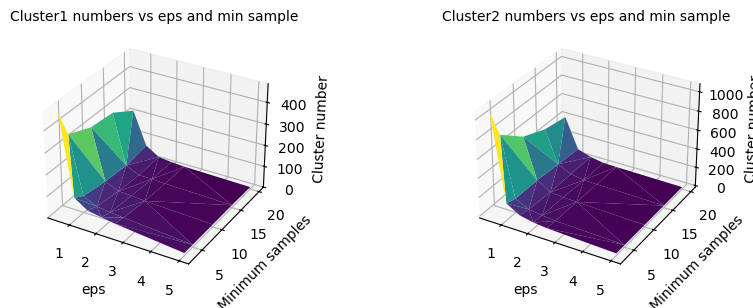

In [16]:
acc_np = np.array(acc)

fig = plt.figure(figsize=(10,3))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_trisurf(acc_np[:,0],acc_np[:,1],acc_np[:,2], cmap='viridis')
ax1.set_title(f"Cluster1 numbers vs eps and min sample" ,fontsize=10)
ax1.set_xlabel('eps')
ax1.set_ylabel('Minimum samples')
ax1.set_zlabel('Cluster number')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_trisurf(acc_np[:,0],acc_np[:,1],acc_np[:,3], cmap='viridis')
ax2.set_title(f"Cluster2 numbers vs eps and min sample" ,fontsize=10)
ax2.set_xlabel('eps')
ax2.set_ylabel('Minimum samples')
ax2.set_zlabel('Cluster number')

plt.tight_layout()
plt.show()

filename="ClusterNo_eps_MinSample_Effect.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')


By increasing the eps, the number of clusters decreases very fast since more neighbors stay in one cluster with higher radius. By increasing minimum sample, the number of clusters also decreases but slower since this add more neighbors in one cluster but 1 dimensional instead of eps that is in 2 dimensions (area).

### Optimal eps by Elbow Point 
When working with clustering, one of the biggest questions is deciding how many clusters actually make sense for a object data. 
The elbow method helps answer this in a simple way. By selecting specific number of neighbors and find the maximum distance of them, it observes that the sorted distance of these neighbors gradually increases until a specific point that this distance start increasing abruptly. This means those neighbors points are really far from each other and most probably doesn't belong to an object. The elbow point is when this neighbor points distances start increasing suddenly. This point is often selected as the best trade-off between accuracy and simplicity. 

To make the clustering process faster and more efficient, especially for large datasets, a KD-tree structure can be used to quickly find nearby points during cluster assignment. This reduces computational time considerably while still preserving the same overall clustering behavior and helping identify the optimal number of clusters more effectively. In the following section, above discussed distances are calculated by KD-tree methodology.


The KD-Tree (K-Dimensional Tree) method is commonly used to quickly find points that are close to a specific GPS location. Instead of checking the distance to every single point in the dataset, the KD-Tree organizes the data in a smart hierarchical structure that makes searching much more efficient. 

The algorithm repeatedly divides the space into smaller regions by splitting the data along one coordinate at a time, such as latitude or longitude. As a result, large areas that are clearly far away from the target point can be ignored immediately during the search process. This significantly reduces computation time and makes KD-Tree very effective for nearest neighbor searches in low and medium dimensional datasets.

When working with geographic coordinates, using ordinary Euclidean distance is not always accurate because it assumes the Earth is flat. Since the Earth is approximately spherical, the Haversine formula is often used to calculate the shortest distance between two GPS points along the Earth's surface.

Following code shows the implementation of this method:
- The idx (index) array tells us which points are the nearest neighbors. It contains the integer indices representing the positions of those neighboring points in the original dataset.
- The distance array tells us how far away those neighbors are. It contains the numerical distance values between the query point and each corresponding neighbor found in the idx array.



In [17]:
neighbor_no1 = 5 #min_samples1 
neighbor_no2 = 5 #min_samples2
tree1 = KDTree(pcd1_above_ground)
tree2 = KDTree(pcd2_above_ground)
distances1, idx1 = tree1.query(pcd1_above_ground, k=neighbor_no1)
distances2, idx2 = tree2.query(pcd2_above_ground, k=neighbor_no2)
k_distances1_sorted = np.sort(distances1[:,neighbor_no1-1]) # farthest neighbor distance
k_distances2_sorted = np.sort(distances2[:,neighbor_no2-1]) # farthest neighbor distance

As it has been explained above, the sorted distances are monitored for elbow point. Since the number of data is very high, the histogram is used to show where all these data are more frequently located. Both figures are zoomed in to show the detail for finding the right elbow point. 

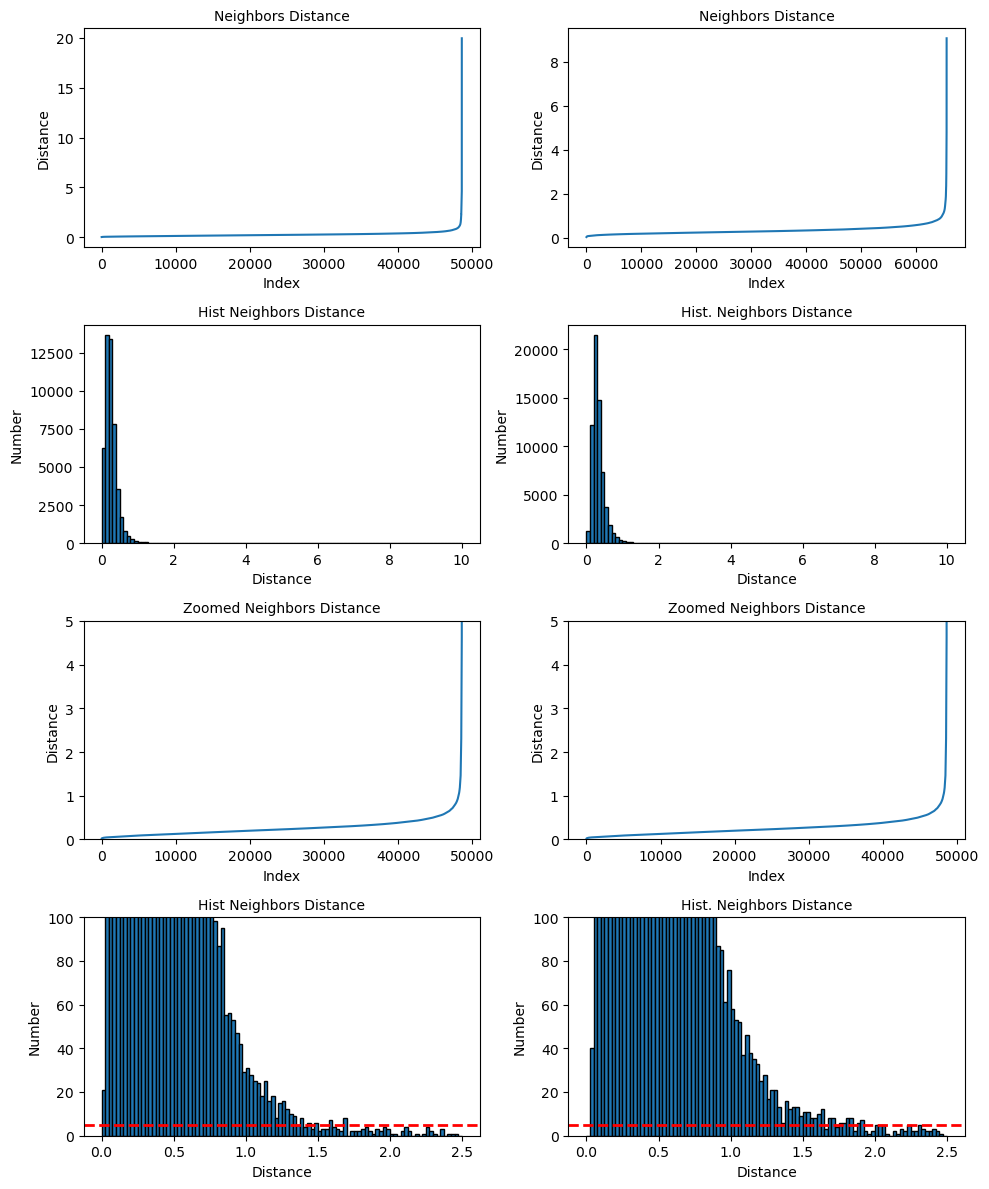

In [18]:
fig = plt.figure(figsize=(10,12))
ax1 = fig.add_subplot(4, 2, 1)
ax1.plot(k_distances1_sorted)
ax1.set_title(f"Neighbors Distance" ,fontsize=10)
ax1.set_xlabel('Index')
ax1.set_ylabel('Distance')

ax2 = fig.add_subplot(4, 2, 2)
ax2.plot(k_distances2_sorted)
ax2.set_title(f"Neighbors Distance" ,fontsize=10)
ax2.set_xlabel('Index')
ax2.set_ylabel('Distance')

ax3 = fig.add_subplot(4, 2, 3)
ax3.hist(k_distances1_sorted, bins=100,range=(0,10), edgecolor='black')
ax3.set_title(f"Hist Neighbors Distance" ,fontsize=10)
ax3.set_xlabel('Distance')
ax3.set_ylabel('Number')

ax4 = fig.add_subplot(4, 2, 4)
ax4.hist(k_distances2_sorted, bins=100,range=(0,10), edgecolor='black')
ax4.set_title(f"Hist. Neighbors Distance" ,fontsize=10)
ax4.set_xlabel('Distance')
ax4.set_ylabel('Number')

ax5 = fig.add_subplot(4, 2, 5)
ax5.plot(k_distances1_sorted)
ax5.set_ylim(0,5)
ax5.set_title(f"Zoomed Neighbors Distance" ,fontsize=10)
ax5.set_xlabel('Index')
ax5.set_ylabel('Distance')

ax6 = fig.add_subplot(4, 2, 6)
ax6.plot(k_distances1_sorted)
ax6.set_ylim(0,5)
ax6.set_title(f"Zoomed Neighbors Distance" ,fontsize=10)
ax6.set_xlabel('Index')
ax6.set_ylabel('Distance')

ax7 = fig.add_subplot(4, 2, 7)
ax7.hist(k_distances1_sorted, bins=100,range=(0,2.5), edgecolor='black')
ax7.set_title(f"Hist Neighbors Distance" ,fontsize=10)
ax7.axhline(y=5, color='red', linestyle='--', linewidth=2)
ax7.set_ylim(0,100)
ax7.set_xlabel('Distance')
ax7.set_ylabel('Number')

ax8 = fig.add_subplot(4, 2, 8)
ax8.hist(k_distances2_sorted, bins=100,range=(0,2.5), edgecolor='black')
ax8.set_title(f"Hist. Neighbors Distance" ,fontsize=10)
ax8.axhline(y=5, color='red', linestyle='--', linewidth=2)
ax8.set_ylim(0,100)
ax8.set_xlabel('Distance')
ax8.set_ylabel('Number')


plt.tight_layout()
plt.show()

filename="ElbowPoint.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')


Above graphs show the distance or eps vs indexes. Most of neigbor points have small distances (eps) less than 1 but there are still some points above 1. As we discussed before, Small eps results many tiny clusters or many noise points and Large eps results clusters merge together. since we are going to use the biggest span for selection of catenary, selection of right eps helps to select bigger portion of it in one cluster selection. If we consider that only 5 points, as a threshold, have distance less than x value (red line), eps can be extracted around 1.5 for dataset1 and 2 for dataset 2. The value of threshold could be considered another value that can affect selected eps.

based on discussion on "DBSCAN Analysis" section, the number of eps and min samples can affect the number of clusters effectively.

In [19]:
optimal_eps1 = 1.5
optimal_eps2 = 2
min_samples1 = 5
min_samples2 = 5
# find the elbow
clustering1 = DBSCAN(eps = optimal_eps1, min_samples=min_samples1).fit(pcd1_above_ground)
clustering2 = DBSCAN(eps = optimal_eps2, min_samples=min_samples2).fit(pcd2_above_ground)
labels1 = clustering1.labels_
labels2 = clustering2.labels_
clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)
colors1 = [plt.cm.Spectral(each) for each in np.linspace(0, 1, clusters1)]
clusters2 = len(set(labels2)) - (1 if -1 in labels2 else 0)
colors2 = [plt.cm.Spectral(each) for each in np.linspace(0, 1, clusters2)]
print(f"Number of cluster:dataset1= {clusters1}, dataset2= {clusters2}")

Number of cluster:dataset1= 48, dataset2= 41


In this step points that are out of selected clusters are filter out.

In [20]:
print(f"Dataset1 filtered point= {len(labels1)-len(labels1[labels1!=-1])}")
pcd1_above_ground_filtered=pcd1_above_ground[labels1!=-1]
labels1_filtered=labels1[labels1!=-1]
print(f"Dataset2 filtered point= {len(labels2)-len(labels2[labels2!=-1])}")
pcd2_above_ground_filtered=pcd2_above_ground[labels2!=-1]
labels2_filtered=labels2[labels2!=-1]


Dataset1 filtered point= 107
Dataset2 filtered point= 79


After filtering the data, the valid data is plotted to show dedicated clusters based on eps and min samples with different color.

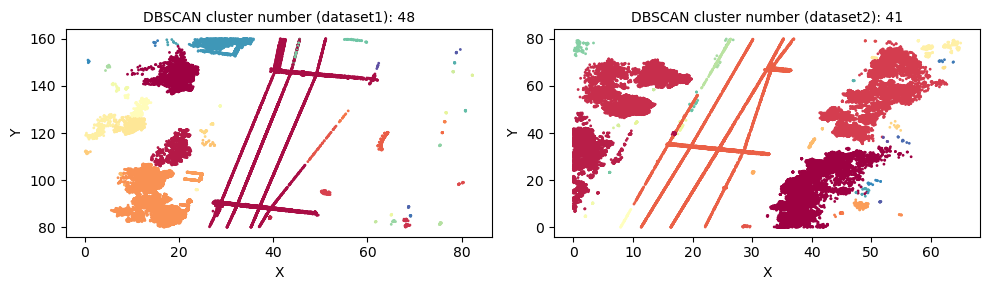

In [21]:
fig = plt.figure(figsize=(10,3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(pcd1_above_ground_filtered[:,0], 
            pcd1_above_ground_filtered[:,1],
            c=labels1_filtered,
            cmap=matplotlib.colors.ListedColormap(colors1),
            s=1)
ax1.set_title(f"DBSCAN cluster number (dataset1): {clusters1}" ,fontsize=10)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(pcd2_above_ground_filtered[:,0], 
            pcd2_above_ground_filtered[:,1],
            c=labels2_filtered,
            cmap=matplotlib.colors.ListedColormap(colors2),
            s=1)
ax2.set_title(f"DBSCAN cluster number (dataset2): {clusters2}" ,fontsize=10)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

filename="Clustered_Cloud_withoutground_optimal_eps.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')

### Finding Catenary
Based on 2D and 3D figures of datasets, there is an expectation that the biggest cluster span belongs to Catenary therefore a function is prepared to extract the biggest cluster span as follow:

In [22]:
catenary1=biggest_cluster(pcd1_above_ground_filtered,labels1_filtered)
catenary2=biggest_cluster(pcd2_above_ground_filtered,labels2_filtered)

The results including the biggest cluster label, cluster span and min and max X and Y for each dataset are extracted. 

In [23]:
cluster_data_show(catenary1,f"dataset1 data (eps={optimal_eps1}, min_sample={min_samples1})")
cluster_data_show(catenary2,f"dataset2 data (eps={optimal_eps2}, min_sample={min_samples2})")

dataset1 data (eps=1.5, min_sample=5): 
Cluster Label : 1
Cluster span: 115.583
min(x) of dataset1 : 26.498
max(x) : 62.140
min(y) : 80.019
max(y) : 159.960

dataset2 data (eps=2, min_sample=5): 
Cluster Label : 7
Cluster span: 106.761
min(x) of dataset1 : 26.498
max(x) : 37.007
min(y) : 0.043
max(y) : 79.976



Finally, the selected cluster which has the biggest span and belongs to Catenary is plotted here.

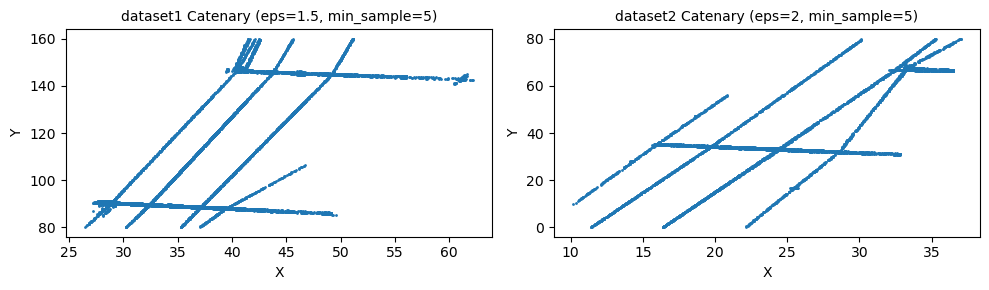

In [24]:
fig = plt.figure(figsize=(10,3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(catenary1['points'][:,0], 
            catenary1['points'][:,1],
            s=1)
ax1.set_title(f"dataset1 Catenary (eps={optimal_eps1}, min_sample={min_samples1})" ,fontsize=10)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(catenary2['points'][:,0], 
            catenary2['points'][:,1],
            s=1)
ax2.set_title(f"dataset2 Catenary (eps={optimal_eps2}, min_sample={min_samples2})" ,fontsize=10)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.show()

filename="Catenary_with_optimal_eps.png"
fig.savefig(filename, dpi=300, bbox_inches='tight')

## Discussion and Summary
In this assignment, two LiDAR point cloud datasets were analyzed to identify and extract the catenary structure from environments. The work combined classical point cloud pre processing techniques with density based machine learning clustering methods.

The first challenge in the datasets was the large amount of ground points. Since the ground occupied a major portion of the point cloud, directly applying clustering on the raw datasets would mainly group the ground surface as the biggest cluster instead of the overhead catenary. To solve this issue, histogram analysis of the Z-axis distribution was used to estimate the dominant ground level. After selecting suitable margins around the histogram peaks, the ground points were removed successfully. This pre processing reduced unnecessary data and improved the effectiveness of the clustering process.

The results showed that ground removal significantly simplified the datasets and reduced computational overhead. Even though some non ground objects such as trees and environmental structures remained, the main overhead objects became much more distinguishable after pre processing.

DBSCAN clustering was selected because it is highly suitable for irregular spatial structures and does not require a predefined number of clusters. One of the most important observations during the assignment was the strong dependency of DBSCAN performance on the parameters eps and min_samples. When the epsilon value was too small, the algorithm generated many disconnected clusters and labeled large portions of valid data as noise. On the other hand, very large epsilon values caused unrelated objects to merge into the same cluster.

To better understand this behavior, different combinations of epsilon and minimum sample values were investigated systematically. The analysis demonstrated that epsilon had a much stronger effect on clustering behavior compared to the minimum sample parameter. Increasing epsilon rapidly reduced the number of clusters because neighboring regions became connected more easily.

The elbow method and KD-tree nearest-neighbor analysis provided a practical approach for selecting suitable epsilon values. By studying the sorted neighbor distances, the transition point between dense object regions and sparse noise regions became visible in elbow figure. Based on this analysis, epsilon values of approximately 1.5 for dataset 1 and 2.0 for dataset 2 produced reasonable clustering results although bigger values can still selected due to limited number of the expected clusters.

After clustering, based on 2D and 3D cloud data about catenary, the largest cluster span was selected as the catenary candidate. This assumption proved effective because the catenary structure extends long distance in X and Y directions compared to other surrounding objects. The extracted clusters showed clear geometric characteristics consistent with overhead catenary wires.

Overall, the assignment demonstrated that combining histogram-based preprocessing, KD-tree neighbor analysis and elbow point selection and DBSCAN clustering can extract railway infrastructure structures from LiDAR point clouds. This work provided valuable practical experience in point cloud processing, parameter tuning, spatial analysis and unsupervised machine learning. 

## Future Work
Several improvements can be considered for future development of this work.

One possible extended work is implementing adaptive or automatic parameter selection for DBSCAN. In the current work, epsilon values were manually selected based on visual interpretation of elbow figure. Machine learning approaches could improve robustness and reduce manual tuning.

The current implementation mainly uses geometric span to identify the catenary. Future work could include additional geometric features such as curvature, orientation, continuity or height consistency to improve detection accuracy.

Using advanced clustering approaches such as HDBSCAN or graph-based segmentation methods could also improve performance in environments with varying point densities. These methods are often more robust when dealing with noisy outdoor LiDAR data.

Finally, LiDAR data can be combined with camera images and GPS information (like vehicle LiDAR + camera + radar). This could improve object classification and provide better understanding of the railway environment. Sensor fusion approaches are widely used in automotive intelligent transportation and autonomous systems and could improve the reliability of catenary detection as well.